In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
import seaborn as sns
import re
import pylab as py
import statsmodels.api as sm
import time
import copy
import math
import itertools
import datetime as dt
import geopandas as gpd   
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, LeaveOneOut, RandomizedSearchCV
from sklearn import datasets, svm, preprocessing, metrics, ensemble, tree, linear_model
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, scale, StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, log_loss, mean_squared_error, r2_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from statsmodels.datasets import get_rdataset
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text, export_graphviz
from IPython.display import Image
from scipy.stats import randint
from datetime import datetime
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import sklearn.model_selection as skm 
from sklearn.tree import DecisionTreeClassifier as DTC
from matplotlib.pyplot import subplots
import os

%matplotlib inline

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# German FinTech Report

## Dataset Overview and Description

The **German FinTech dataset** contains economic and financial information on a sample of predominantly German companies operating in the FinTech sector.

The original dataset includes:

- **978 companies**.
- **16 variables**.
- Two identification variables: company name and company ID.

## Data Cleaning

Before conducting the analysis, a data-cleaning procedure was performed to improve the quality and reliability of the dataset.

Companies with a high number of missing values in the variables of interest were excluded. As a result:

- **31 companies were removed**.
- The final dataset contains **947 usable observations**.

## Variable Transformation

To facilitate the application of quantitative analysis methods, the original `Founding_year` variable was transformed into a new variable called `Age`.

`Age` represents the number of years since the company was founded and is calculated as:

\[
Age = Current year - Founding year
\]

This transformation provides a more interpretable measure of company experience and makes the variable more suitable for subsequent statistical analyses.

In [2]:
# display the first few rows of the dataframe
german_fin = pd.read_excel('German_FinTech.xlsx')
german_fin.head()

,ID,Name,Status,Foundingyear,Founder,Street,Postcode,City,Country,Segment,Subsegment,Bank_Cooperation,Homepage,E-Mail,Insolvency,Liquidation
0,1,CRX Markets,1,2012.0,Moritz von der Linden; Carlo KÃ¶lzer,Landsberger Str. 191,80687,MÃ¼nchen,Germany,Financing,Credit and Factoring,1,https://www.crxmarkets.com/de/,support@crxmarkets.com,0,0
1,2,aifinyo,1,2014.0,Andreas Dubrow; Philipp Kalwies,TiergartenstraÃŸe 8,01219,Dresden,Germany,Financing,Credit and Factoring,0,https://www.aifinyo.de/,andreas.dubrow@decimo.de\ninfo@aifinyo.de,0,0
2,3,fundflow,1,2016.0,Joachim Kaune; Antonio Faralli,Prenzlauer Allee 53,10405,Berlin,Germany,Financing,Credit and Factoring,1,https://fundflow.de/,info@fundflow.de,0,0
3,4,WIR BEWEGEN SH,1,2015.0,Investitionsbank Schleswig-Holstein,FleethÃ¶rn 29-31,24103,Kiel,Germany,Financing,Donation-based Crowdfunding,0,https://www.wir-bewegen.sh/,info@wir-bewegen.sh,0,0
4,5,Zusammen Gutes tun,1,2016.0,NaN,KohlenstraÃŸe 132,34121,Kassel,Germany,Financing,Donation-based Crowdfunding,0,https://www.zusammen-gutes-tun.de/,info@eb.de,0,0


In [3]:
# remove columns with information we're not interested in
german_fin = german_fin.drop(columns=['Street', 'City', 'Name', 'Founder', 'Homepage', 'E-Mail'], axis=1)

In [4]:
# check if there are any cells with Not Available (NA) values
german_fin.isna().any().any()

True

In [5]:
# count the number of rows in the dataset
num_rows = len(german_fin)
print(num_rows)

978


In [6]:
# remove rows that have empty cells
german_fin = german_fin.dropna()

In [7]:
# 31 rows have been removed
num_rows = len(german_fin)
print(num_rows)

947


In [8]:
# convert Foundingyear to integer
german_fin['Foundingyear'] = german_fin['Foundingyear'].astype(int)

In [9]:
# Set the reference year to 2025 (year of the report)
current_year = 2025

# Compute the company age as the difference between the reference year and Foundingyear
german_fin["Age"] = current_year - german_fin["Foundingyear"]  

# Replace Foundingyear with the new Age column, moving it to position 1
colonne = german_fin.columns.tolist()  
colonne.insert(1, colonne.pop(colonne.index("Age")))  
german_fin = german_fin[colonne]  
german_fin = german_fin.drop(columns=['Foundingyear'])

german_fin.head()

,ID,Age,Status,Postcode,Country,Segment,Subsegment,Bank_Cooperation,Insolvency,Liquidation
0,1,13,1,80687,Germany,Financing,Credit and Factoring,1,0,0
1,2,11,1,01219,Germany,Financing,Credit and Factoring,0,0,0
2,3,9,1,10405,Germany,Financing,Credit and Factoring,1,0,0
3,4,10,1,24103,Germany,Financing,Donation-based Crowdfunding,0,0,0
4,5,9,1,34121,Germany,Financing,Donation-based Crowdfunding,0,0,0


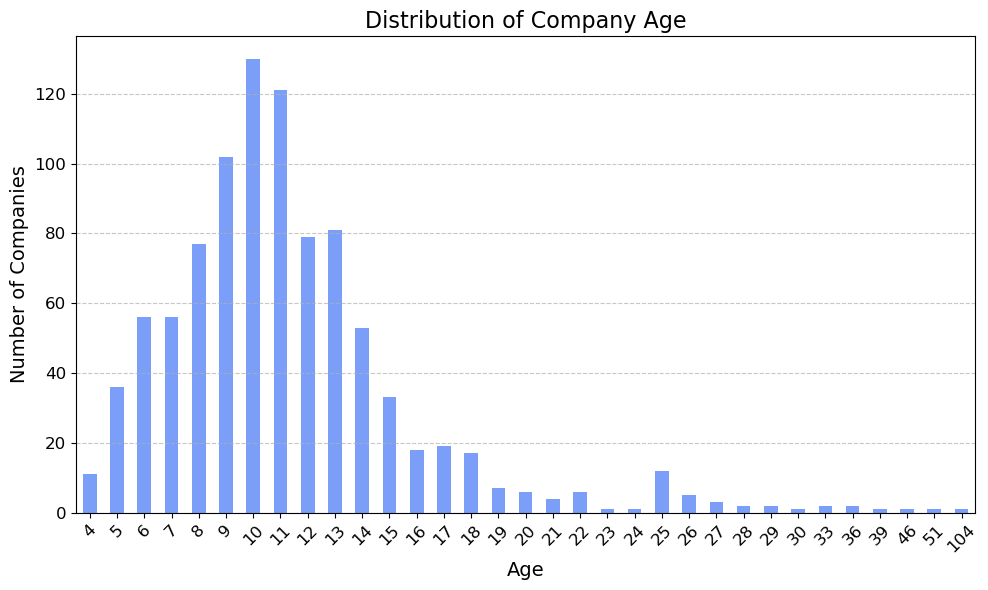

In [10]:
# Age plot
german_fin.Age.value_counts().sort_index().plot(
    kind='bar', 
    color=[cm.coolwarm(0.2)], 
    figsize=(10, 6)
)

plt.title("Distribution of Company Age", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Number of Companies", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Distribution of Company Age

The graph shows the distribution of company age in the dataset.

Most companies are between **7 and 13 years old**, with a peak at **10 years**, corresponding to companies founded in **2015**. In that year, **130 companies** were established, indicating significant growth in the FinTech sector.

Company age ranges from **4 to 104 years**, although extreme values are uncommon. Overall, the distribution is skewed toward younger companies, which is typical of emerging technology sectors.

In [11]:
# How many companies were founded in 2015 (10 years old)
aziende_2015 = german_fin[german_fin['Age'] == 10].shape[0]
print(aziende_2015)

130


## Geographical Distribution

The analyzed sample mainly consists of companies headquartered in Germany. German companies account for **822 of the 947 observations**, representing **86.8%** of the total sample.

The remaining **125 companies**, equivalent to **13.2%**, are headquartered in other countries.

In [12]:
# How many companies are German
count_germany = german_fin[german_fin["Country"] == "Germany"].shape[0]
print(count_germany)

822


In [13]:
# How many companies are not German
count_other = german_fin[german_fin["Country"] != "Germany"].shape[0]
print(count_other)

125


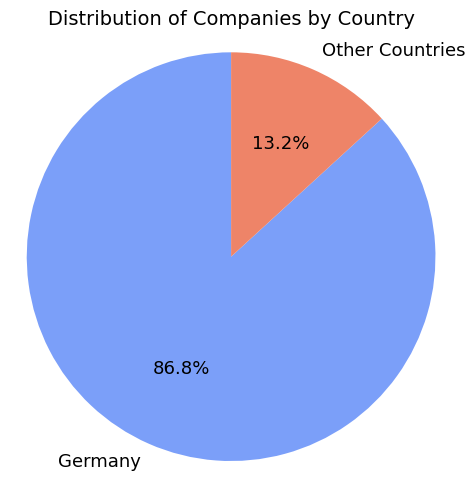

In [14]:
# Pie chart
labels = ["Germany", "Other Countries"]
sizes = [count_germany, count_other]
colors = ["blue", "gray"]

plt.figure(figsize=(5, 5))
plt.pie(
    sizes, 
    labels=labels, 
    autopct="%1.1f%%", 
    colors=[cm.coolwarm(0.2), cm.coolwarm(0.8)], 
    startangle=90
)

plt.title("Distribution of Companies by Country", fontsize=14)
for text in plt.gca().texts:  
    text.set_fontsize(13) 

plt.axis('equal')  
plt.tight_layout()  
plt.show()

## Consistency between Segments and Subsegments

During the preliminary analysis, an inconsistency was identified between the `Segment` and `Subsegment` variables. Specifically, some companies were assigned to the same subsegment but to different segments.

This is inconsistent with the logical structure of the dataset, since each subsegment should belong to a single segment.

Two possible solutions were considered:

1. Removing the inconsistent observations.
2. Correcting the inconsistencies by reassigning the observations.

The second option was chosen in order to preserve as much data as possible.

For each subsegment associated with multiple segments, the most frequent segment was identified. Companies assigned to minority segments within the same subsegment were then reassigned to the predominant segment.

The following corrections were made:

- **Robo-Advice**: 1 company was reassigned from `Financing` to `Asset Management`, resulting in a total of **40 + 1 companies**.
- **Search Engines and Comparison Sites**: 1 company was reassigned from `Financing` to `Other FinTechs`, resulting in a total of **20 + 1 companies**.
- **Alternative Payment Methods**: 1 company was reassigned from `Asset Management` to `Payments`, resulting in a total of **90 + 1 companies**.
- **Other FinTechs**: 53 companies were reassigned from `Payments` to `Other FinTechs`, resulting in a total of **95 + 53 companies**.

After the inconsistent observations were reassigned, a graph was created to represent the distribution of companies across the four segments included in the dataset.

In [15]:
# In the dataset, many companies with the same sub-segment are assigned to different segments; this is not possible.
# For the sub-sector "Robo-Advice":
# - 40 companies are in the "Asset Management" sector
# - 1 company is in the "Financing" sector

In [16]:
count = german_fin[
    (german_fin['Segment'] == 'Asset Management') & 
    (german_fin['Subsegment'] == 'Robo-Advice')
].shape[0]

print("Number of rows:", count)

Number of rows: 40


In [17]:
count = german_fin[
    (german_fin['Segment'] == 'Financing') & 
    (german_fin['Subsegment'] == 'Robo-Advice')
].shape[0]

print("Number of rows:", count)

Number of rows: 1


In [18]:
# For the sub-sector "Search Engines and Comparison Sites":
# - 19 companies are in the "Other FinTechs" sector
# - 1 company is in the "Financing" sector

In [19]:
count = german_fin[
    (german_fin['Segment'] == 'Other FinTechs') & 
    (german_fin['Subsegment'] == 'Search Engines and Comparison Sites')
].shape[0]

print("Number of rows:", count)

Number of rows: 19


In [20]:
count = german_fin[
    (german_fin['Segment'] == 'Financing') & 
    (german_fin['Subsegment'] == 'Search Engines and Comparison Sites')
].shape[0]

print("Number of rows:", count)

Number of rows: 1


In [21]:
# For the sub-sector "Alternative Payment Methods":
# - 89 companies are in the "Payments" sector
# - 1 company is in the "Asset Management" sector

In [22]:
count = german_fin[
    (german_fin['Segment'] == 'Payments') & 
    (german_fin['Subsegment'] == 'Alternative Payment Methods')
].shape[0]

print("Number of rows:", count)

Number of rows: 89


In [23]:
count = german_fin[
    (german_fin['Segment'] == 'Asset Management') & 
    (german_fin['Subsegment'] == 'Alternative Payment Methods')
].shape[0]

print("Number of rows:", count)

Number of rows: 1


In [24]:
# For the sub-sector "Other FinTechs":
# - 53 companies are in the "Payments" sector
# - 95 companies are in the "Other FinTechs" sector

In [25]:
count = german_fin[
    (german_fin['Segment'] == 'Other FinTechs') & 
    (german_fin['Subsegment'] == 'Other FinTechs')
].shape[0]

print("Number of rows:", count)

Number of rows: 95


In [26]:
count = german_fin[
    (german_fin['Segment'] == 'Payments') & 
    (german_fin['Subsegment'] == 'Other FinTechs')
].shape[0]

print("Number of rows:", count)

Number of rows: 53


In [27]:
# Possible solutions:
# - Remove the observations, or
# - Reassign them to the correct segment

In [28]:
# Reassignment

In [29]:
german_fin.loc[(german_fin["Segment"] == "Financing") & (german_fin["Subsegment"] == "Robo-Advice"), "Segment"] = "Asset Management"

In [30]:
german_fin.loc[(german_fin["Segment"] == "Financing") & (german_fin["Subsegment"] == "Search Engines and Comparison Sites"), "Segment"] = "Other FinTechs"

In [31]:
german_fin.loc[(german_fin["Segment"] == "Asset Management") & (german_fin["Subsegment"] == "Alternative Payment Methods"), "Segment"] = "Payments"

In [32]:
german_fin.loc[(german_fin["Segment"] == "Payments") & (german_fin["Subsegment"] == "Other FinTechs"), "Segment"] = "Other FinTechs"

In [33]:
# check

In [34]:
count = german_fin[(german_fin['Segment'] == 'Asset Management') & (german_fin['Subsegment'] == 'Robo-Advice')].shape[0]

print("Number of rows:", count)

Number of rows: 41


In [35]:
count = german_fin[(german_fin['Segment'] == 'Financing') & (german_fin['Subsegment'] == 'Robo-Advice')].shape[0]

print("Number of rows:", count)

Number of rows: 0


In [36]:
count = german_fin[(german_fin['Segment'] == 'Other FinTechs') & (german_fin['Subsegment'] == 'Search Engines and Comparison Sites')].shape[0]

print("Number of rows:", count)

Number of rows: 20


In [37]:
count = german_fin[(german_fin['Segment'] == 'Financing') & (german_fin['Subsegment'] == 'Search Engines and Comparison Sites')].shape[0]

print("Number of rows:", count)

Number of rows: 0


In [38]:
count = german_fin[(german_fin['Segment'] == 'Payments') & (german_fin['Subsegment'] == 'Alternative Payment Methods')].shape[0]

print("Number of rows:", count)

Number of rows: 90


In [39]:
count = german_fin[(german_fin['Segment'] == 'Asset Management') & (german_fin['Subsegment'] == 'Alternative Payment Methods')].shape[0]

print("Number of rows:", count)

Number of rows: 0


In [40]:
count = german_fin[(german_fin['Segment'] == 'Other FinTechs') & (german_fin['Subsegment'] == 'Other FinTechs')].shape[0]

print("Number of rows:", count)

Number of rows: 148


In [41]:
count = german_fin[(german_fin['Segment'] == 'Payments') & (german_fin['Subsegment'] == 'Other FinTechs')].shape[0]

print("Number of rows:", count)

Number of rows: 0


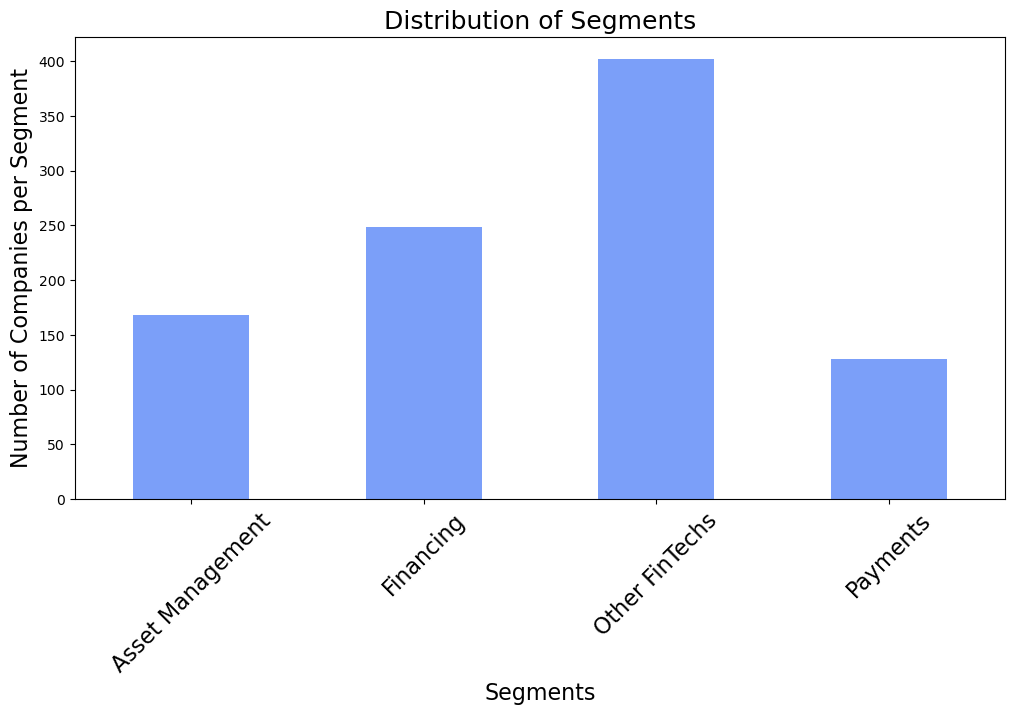

In [42]:
# Distribution of companies by segment
plt.figure(figsize=(12, 6))  
german_fin.Segment.value_counts().sort_index().plot(
    kind='bar', 
    color=[cm.coolwarm(0.2)]
)
plt.title("Distribution of Segments", fontsize=18)
plt.xlabel('Segments', fontsize=16)
plt.ylabel('Number of Companies per Segment', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.show()

In [43]:
# How many companies are in Asset Management
AM = german_fin[(german_fin['Segment'] == 'Asset Management')]
numero_AM = AM.shape[0]

print(numero_AM)

168


In [44]:
# How many companies are in Financing
Financing = german_fin[(german_fin['Segment'] == 'Financing')]
numero_Financing = Financing.shape[0]

print(numero_Financing)

249


In [45]:
# How many companies are in Other FinTechs
OFT = german_fin[(german_fin['Segment'] == 'Other FinTechs')]
numero_OFT = OFT.shape[0]

print(numero_OFT)

402


In [46]:
# How many companies are in Payments
Payments = german_fin[(german_fin['Segment'] == 'Payments')]
numero_Payments = Payments.shape[0]

print(numero_Payments)

128


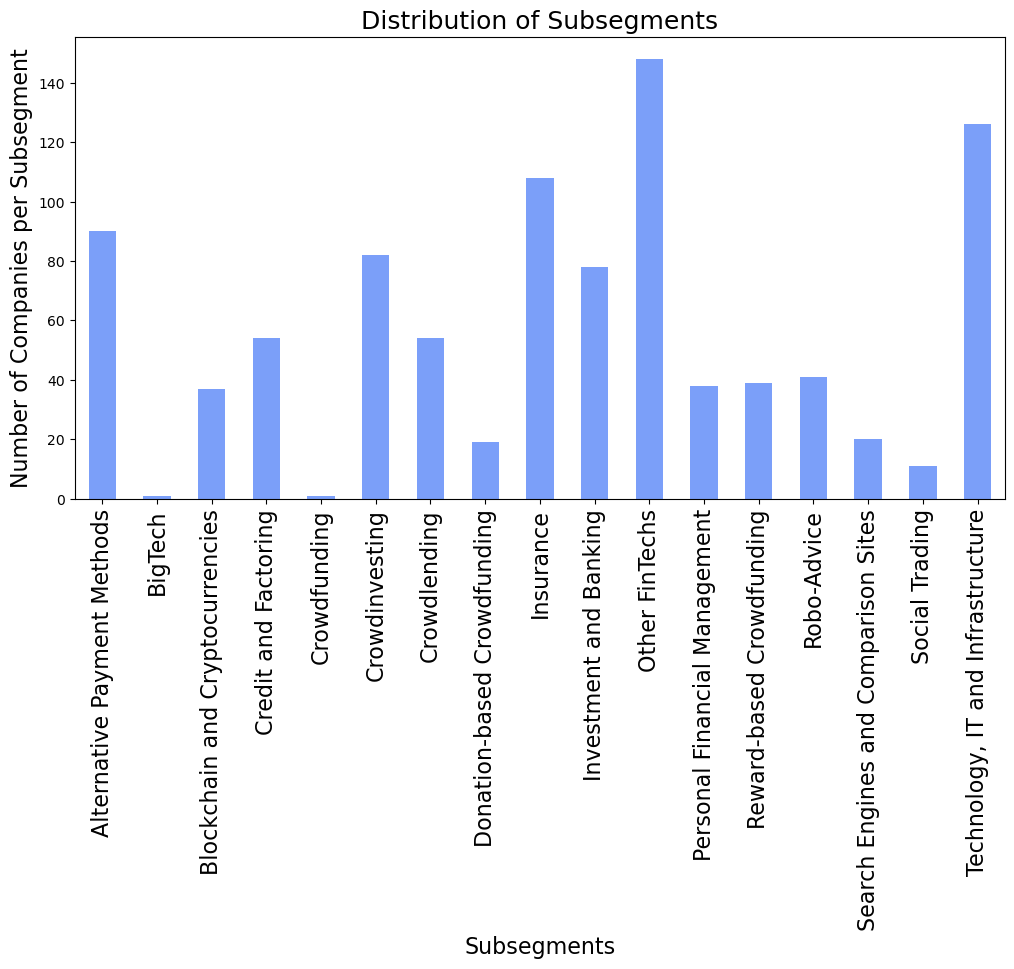

In [47]:
# Distribution of subsegments
plt.figure(figsize=(12, 6))  
german_fin.Subsegment.value_counts().sort_index().plot(
    kind='bar', 
    color=[cm.coolwarm(0.2)]
)
plt.title("Distribution of Subsegments", fontsize=18)
plt.xlabel('Subsegments', fontsize=16)
plt.ylabel('Number of Companies per Subsegment', fontsize=16)
plt.xticks(rotation=90, fontsize=16)
plt.show()

## Distribution of Binary Variables

The dataset contains four binary variables:

- `Status`
- `Bank_Cooperation`
- `Insolvency`
- `Liquidation`

For each variable, a bar chart is provided to show the distribution of its respective categories.

Text(0, 0.5, 'Number of Companies')

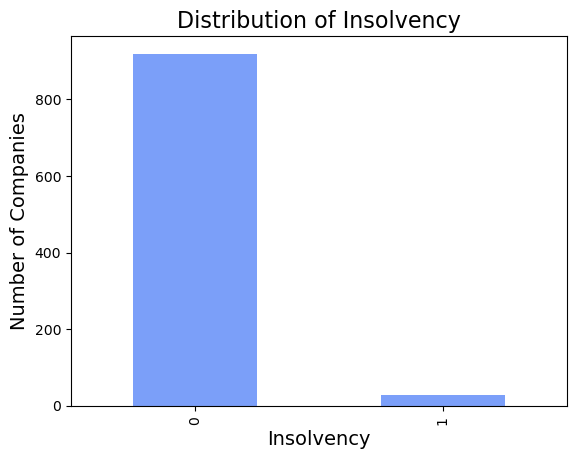

In [48]:
german_fin.Insolvency.value_counts().sort_index().plot(
    kind='bar',
    color=[cm.coolwarm(0.2)]
)
plt.title("Distribution of Insolvency", fontsize=16)
plt.xlabel('Insolvency', fontsize=14)
plt.ylabel('Number of Companies', fontsize=14)

Text(0, 0.5, 'Number of Companies')

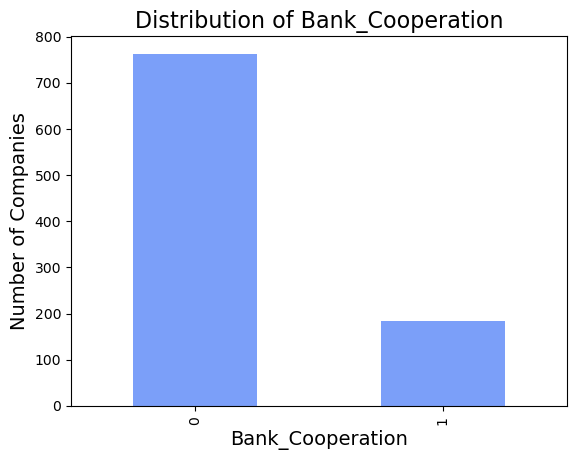

In [49]:
german_fin.Bank_Cooperation.value_counts().sort_index().plot(kind='bar',color=[cm.coolwarm(0.2)])
plt.title("Distribution of Bank_Cooperation", fontsize=16)
plt.xlabel('Bank_Cooperation', fontsize=14)
plt.ylabel('Number of Companies', fontsize=14)

Text(0, 0.5, 'Number of Companies')

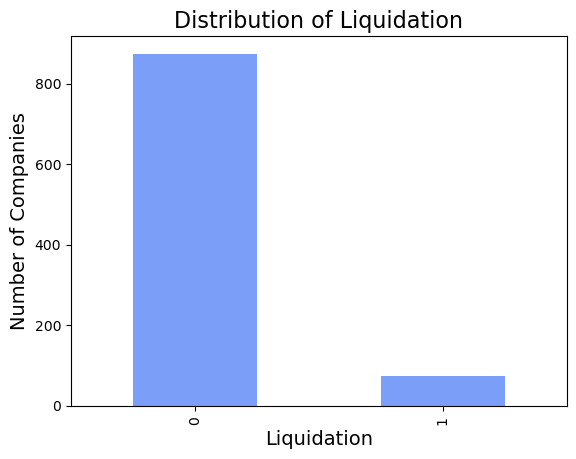

In [50]:
german_fin.Liquidation.value_counts().sort_index().plot(kind='bar',color=[cm.coolwarm(0.2)])
plt.title("Distribution of Liquidation", fontsize=16)
plt.xlabel('Liquidation', fontsize=14)
plt.ylabel('Number of Companies', fontsize=14)

Text(0, 0.5, 'Number of Companies')

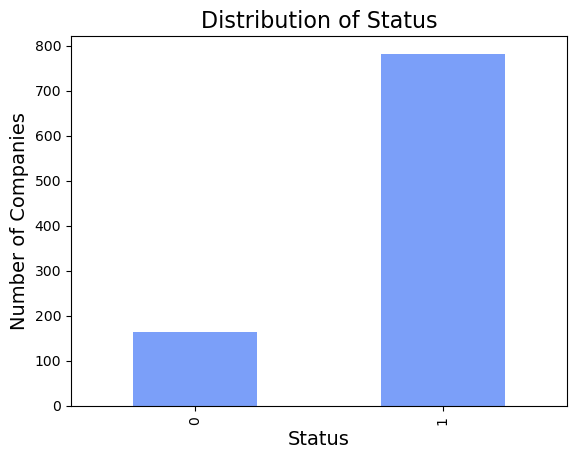

In [51]:
german_fin.Status.value_counts().sort_index().plot(kind='bar',color=[cm.coolwarm(0.2)])
plt.title("Distribution of Status", fontsize=16)
plt.xlabel('Status', fontsize=14)
plt.ylabel('Number of Companies', fontsize=14)

In [52]:
# Compute the correlation matrix between selected variables
german_fin[["Status", "Age", "Bank_Cooperation", "Insolvency", "Liquidation"]].corr(numeric_only=True)

,Status,Age,Bank_Cooperation,Insolvency,Liquidation
Status,1.000000,0.004551,0.155211,-0.199215,-0.629169
Age,0.004551,1.000000,-0.033219,0.034789,0.017822
Bank_Cooperation,0.155211,-0.033219,1.000000,0.008818,-0.141923
Insolvency,-0.199215,0.034789,0.008818,1.000000,-0.050446
Liquidation,-0.629169,0.017822,-0.141923,-0.050446,1.000000


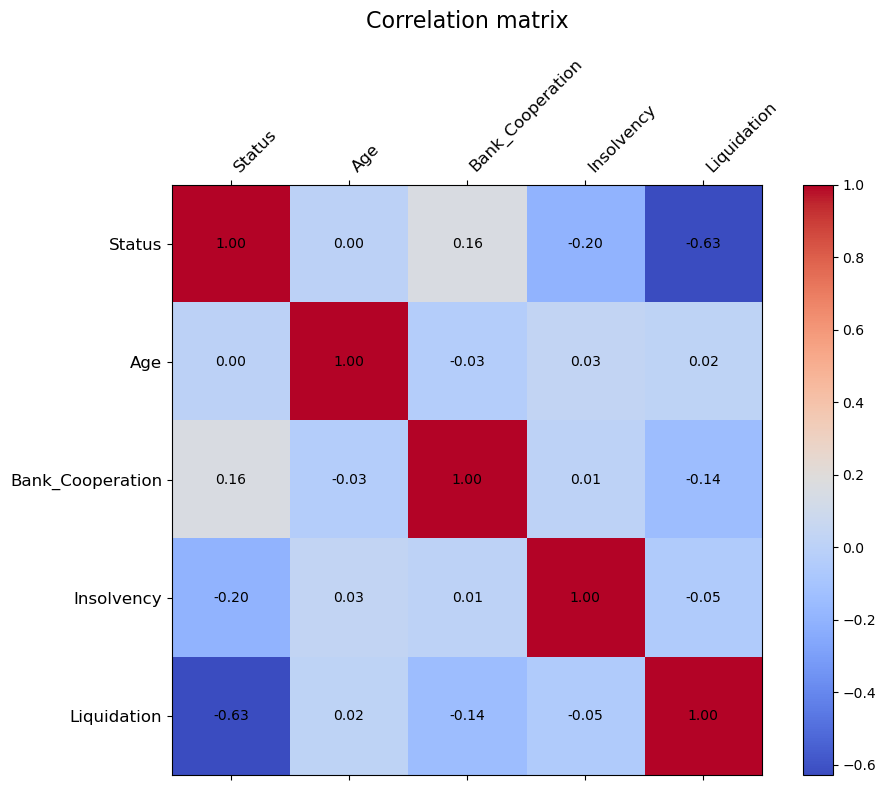

In [53]:
corr_matrix = german_fin[["Status", "Age", "Bank_Cooperation", "Insolvency", "Liquidation"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap="coolwarm")
fig.colorbar(cax)
ax.set_xticks(np.arange(corr_matrix.shape[1]))
ax.set_yticks(np.arange(corr_matrix.shape[0]))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="left", fontsize=12)
ax.set_yticklabels(corr_matrix.columns, fontsize=12)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=10)
ax.set_title("Correlation matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## Correlation between Status and Liquidation

A strong negative correlation was observed between `Status` and `Liquidation`, with a correlation coefficient of **-0.63**.

To avoid redundancy in the subsequent analyses, only the `Status` variable will be retained.

In [54]:
# Create a correlation matrix including p-values
data = german_fin[["Status", "Age", "Bank_Cooperation", "Insolvency", "Liquidation"]]

def correlation_with_pvalues(df):
    cols = df.columns
    n = len(cols)
    
    corr_matrix = np.zeros((n, n))
    pval_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                # Perfect correlation on the diagonal
                corr_matrix[i, j] = 1.0
                pval_matrix[i, j] = 0.0
            else:
                # Compute correlation and p-value
                corr, pval = pearsonr(df[cols[i]], df[cols[j]])
                corr_matrix[i, j] = corr
                pval_matrix[i, j] = pval
                
    # Convert matrices to DataFrames for readability
    corr_df = pd.DataFrame(corr_matrix, index=cols, columns=cols)
    pval_df = pd.DataFrame(pval_matrix, index=cols, columns=cols)
    
    return corr_df, pval_df

correlation_matrix, pvalue_matrix = correlation_with_pvalues(data)

print("Correlation matrix:")
print(correlation_matrix)

print("\nP-value matrix:")
print(pvalue_matrix)

Correlation matrix:
                    Status       Age  Bank_Cooperation  Insolvency  \
Status            1.000000  0.004551          0.155211   -0.199215   
Age               0.004551  1.000000         -0.033219    0.034789   
Bank_Cooperation  0.155211 -0.033219          1.000000    0.008818   
Insolvency       -0.199215  0.034789          0.008818    1.000000   
Liquidation      -0.629169  0.017822         -0.141923   -0.050446   

                  Liquidation  
Status              -0.629169  
Age                  0.017822  
Bank_Cooperation    -0.141923  
Insolvency          -0.050446  
Liquidation          1.000000  

P-value matrix:
                         Status       Age  Bank_Cooperation    Insolvency  \
Status             0.000000e+00  0.888760          0.000002  6.229592e-10   
Age                8.887597e-01  0.000000          0.307157  2.848558e-01   
Bank_Cooperation   1.593312e-06  0.307157          0.000000  7.863872e-01   
Insolvency         6.229592e-10  0.284856 

In [55]:
# Status and Liquidation are highly (negatively) correlated; we will use only Status in the analysis
# Create new dummy variables to represent the sectors

In [56]:
# Create dummy variables
german_fin['Financing'] = (german_fin['Segment'] == "Financing").astype(int)
german_fin['Other FinTechs'] = (german_fin['Segment'] == "Other FinTechs").astype(int)
german_fin['Payments'] = (german_fin['Segment'] == "Payments").astype(int)

# Check the result
german_fin.head()

,ID,Age,Status,Postcode,Country,Segment,Subsegment,Bank_Cooperation,Insolvency,Liquidation,Financing,Other FinTechs,Payments
0,1,13,1,80687,Germany,Financing,Credit and Factoring,1,0,0,1,0,0
1,2,11,1,01219,Germany,Financing,Credit and Factoring,0,0,0,1,0,0
2,3,9,1,10405,Germany,Financing,Credit and Factoring,1,0,0,1,0,0
3,4,10,1,24103,Germany,Financing,Donation-based Crowdfunding,0,0,0,1,0,0
4,5,9,1,34121,Germany,Financing,Donation-based Crowdfunding,0,0,0,1,0,0


# Segment mapping

In [57]:
# Load the Germany shapefile
shapefile = 'germany_map.geojson'
geo_data = gpd.read_file(shapefile)

In [58]:
# Extract the Leitzone (postal code region) from the shapefile (first two digits of the ZIP code)
geo_data['Leitzone'] = geo_data['plz'].astype(str).str[:2]

In [59]:
# Filter only German companies
german_only = german_fin[german_fin['Country'] == 'Germany'].copy()

In [60]:
# Create the Leitzone variable for these companies as well
german_only['Postcode'] = german_only['Postcode'].astype(str)
german_only['Leitzone'] = german_only['Postcode'].str[:2]

In [61]:
# Find the most common segment for each Leitzone
segment_per_leitzone = (
    german_only.groupby('Leitzone')['Segment']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)

In [62]:
# Merge this information into the GeoDataFrame
geo_data = geo_data.merge(segment_per_leitzone, on='Leitzone', how='left')

In [63]:
# Colors for segments
segmenti_unici = geo_data['Segment'].dropna().unique()
colori_base = [cm.coolwarm(0.25), cm.coolwarm(1), cm.coolwarm(0.99), cm.coolwarm(0.8)]
colori = colori_base[:len(segmenti_unici)] + [cm.coolwarm(0.5)]  # Add a color for missing values

In [64]:
# Map each segment to a numeric code
segment_dict = {segment: i for i, segment in enumerate(segmenti_unici)}
geo_data['Segment_Code'] = geo_data['Segment'].map(segment_dict)
geo_data['Segment_Code'] = geo_data['Segment_Code'].fillna(-1)  # -1 for missing data

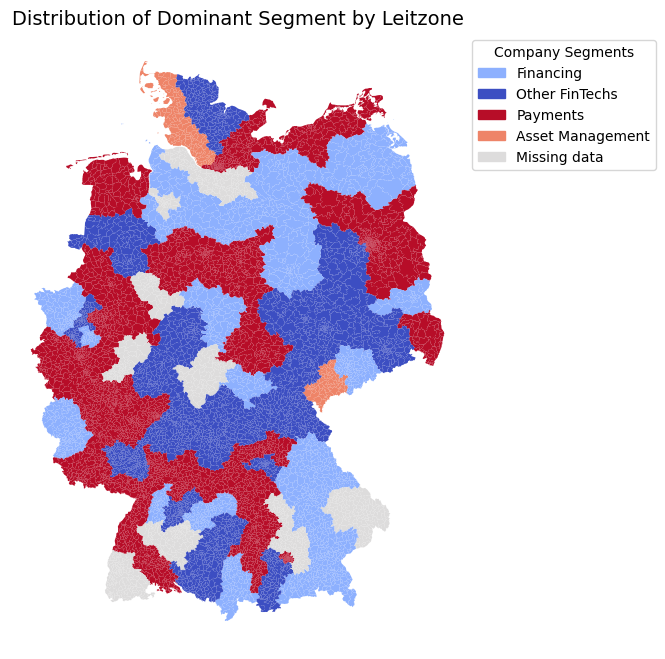

In [65]:
cmap_segment = ListedColormap(colori)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
geo_data.plot(column='Segment_Code', cmap=cmap_segment, legend=False, ax=ax)

ax.set_title('Distribution of Dominant Segment by Leitzone', fontsize=14)
ax.axis('off')

legend_labels = [
    mpatches.Patch(color=colori[i], label=segment)
    for i, segment in enumerate(segmenti_unici)
]
legend_labels.append(mpatches.Patch(color=cm.coolwarm(0.5), label="Missing data"))

ax.legend(handles=legend_labels, title="Company Segments", loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

## Geographic Distribution of the Predominant Segment

The map shows the distribution of the predominant company segment across different geographical areas of Germany, classified by `Leitzone`.

A `Leitzone` is a postal area used by the German postal code system and represents a regional territorial subdivision.

The analysis includes only companies headquartered in Germany, excluding companies located in other countries. Areas shown in grey do not contain any companies from the dataset.

Overall, the geographical distribution of the different segments appears to be relatively homogeneous.

## Variables Included in the Models

In both models, the dependent variable, `Status`, was analyzed as a function of the following explanatory variables:

- **`Bank_Cooperation`**: a binary variable indicating whether the company cooperates with a bank.
- **`Liquidation`**: a binary variable indicating whether the company is undergoing liquidation.
- **`Age`**: a quantitative variable representing the company’s age.
- **`Segment`**: a categorical variable identifying the company’s economic sector, divided into four categories.

To include `Segment` in the statistical models, it was encoded using three binary dummy variables, each representing one of the four segments. The fourth category was used as the reference category, or **baseline**, and was therefore not explicitly encoded. This approach avoids ambiguity and redundancy in the model specification.

At the end of the analysis, the results obtained from the two models were discussed and compared.

## Logistic Regression

To apply logistic regression, the dataset was divided into a **training set**, containing 67% of the observations, and a **validation set**, containing the remaining 33%.

The model was first trained using the observations in the training set. It was then tested on the previously unseen observations in the validation set.

The performance of the logistic regression model was evaluated using several metrics:

- The confusion matrix.
- Standard classification metrics.
- The Receiver Operating Characteristic (ROC) curve.
- The Area Under the Curve (AUC) value.

In [66]:
# To compute p-values, we use statsmodels
# scikit-learn does not support this functionality
# We use sm.Logit() instead of LogisticRegression

In [67]:
X = german_fin.drop(['ID','Status','Country','Segment','Subsegment','Liquidation',"Postcode"], axis=1)
y = german_fin['Status']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [69]:
# Add a constant term (required for statsmodels)
X_train_const = sm.add_constant(X_train)

In [70]:
# Create the model
model = sm.Logit(y_train, X_train_const)

In [71]:
# Fit the logistic regression model
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.409331
         Iterations 7


In [72]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                 Status   No. Observations:                  634
Model:                          Logit   Df Residuals:                      627
Method:                           MLE   Df Model:                            6
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                  0.1175
Time:                        01:43:27   Log-Likelihood:                -259.52
converged:                       True   LL-Null:                       -294.08
Covariance Type:            nonrobust   LLR p-value:                 6.172e-13
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.9576      0.410      4.770      0.000       1.153       2.762
Age                  0.0112      0.022      0.516      0.606      -0.031       0.054
Bank_Cooperation     1.5897 

In [73]:
logreg = LogisticRegression(random_state=16)
logreg.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [74]:
y_pred = logreg.predict(X_test)
probabilities = logreg.predict_proba(X_test)

In [75]:
# Intercept and coefficients
print("Intercept:", logreg.intercept_)
print("Coefficients:", logreg.coef_)

Intercept: [1.8013569]
Coefficients: [[ 0.00876469  1.33328341 -1.89506905 -1.08931658  0.11128575 -0.70685016]]


In [76]:
# Probability of each observation being classified as 0 or 1
logreg.predict_proba(X_test)

array([[0.1313581 , 0.8686419 ],
       [0.07600499, 0.92399501],
       [0.10593331, 0.89406669],
       [0.10265842, 0.89734158],
       [0.31009243, 0.68990757],
       [0.34770722, 0.65229278],
       [0.74275228, 0.25724772],
       [0.30635482, 0.69364518],
       [0.30449547, 0.69550453],
       [0.11643994, 0.88356006],
       [0.11917252, 0.88082748],
       [0.31197062, 0.68802938],
       [0.11734471, 0.88265529],
       [0.31009243, 0.68990757],
       [0.11643994, 0.88356006],
       [0.10604803, 0.89395197],
       [0.13337121, 0.86662879],
       [0.30635482, 0.69364518],
       [0.03866001, 0.96133999],
       [0.11917252, 0.88082748],
       [0.12740922, 0.87259078],
       [0.1313581 , 0.8686419 ],
       [0.21188105, 0.78811895],
       [0.30449547, 0.69550453],
       [0.11464858, 0.88535142],
       [0.11825556, 0.88174444],
       [0.12196038, 0.87803962],
       [0.12261613, 0.87738387],
       [0.07478305, 0.92521695],
       [0.12009563, 0.87990437],
       [0.

In [77]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[  4,  50],
       [  1, 258]])

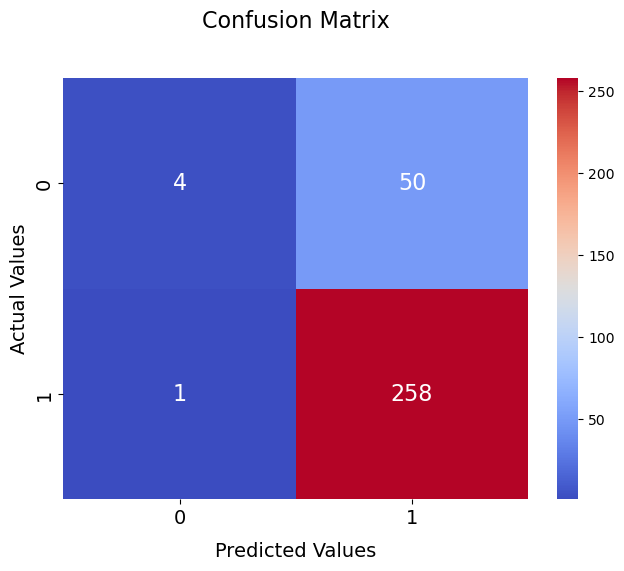

In [78]:
class_names = [0, 1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontsize=14)
plt.yticks(tick_marks, class_names, fontsize=14)

sns.heatmap(
    pd.DataFrame(cnf_matrix), 
    annot=True, 
    cmap="coolwarm", 
    fmt='g',
    annot_kws={'size': 16}, 
    ax=ax
)
ax.xaxis.set_label_position("bottom")  
ax.xaxis.tick_bottom()  
plt.tight_layout()
plt.title('Confusion Matrix', fontsize=16, y=1.1)
plt.ylabel('Actual Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=14, labelpad=10)
plt.show()

In [79]:
target_names = ['0', '1']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

           0       0.80      0.07      0.14        54
           1       0.84      1.00      0.91       259

    accuracy                           0.84       313
   macro avg       0.82      0.54      0.52       313
weighted avg       0.83      0.84      0.78       313



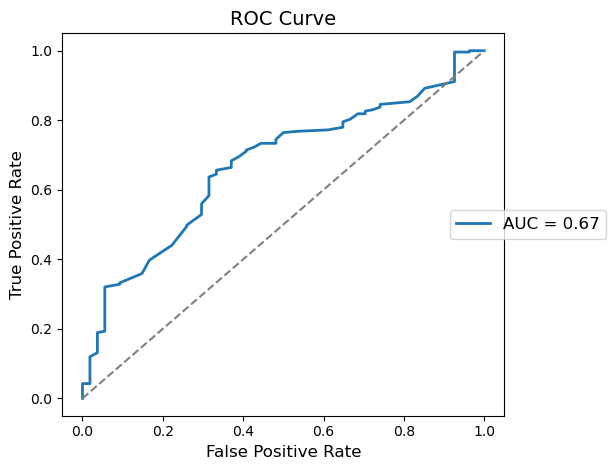

In [80]:
y_pred_proba = logreg.predict_proba(X_test)[::, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc), linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.legend(loc='center right', fontsize=12, bbox_to_anchor=(1.25, 0.5))
plt.title('ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.tight_layout()  # Optimize figure layout
plt.show()

## ROC Curve and AUC

The ROC curve was used to evaluate the model’s discriminatory ability. It represents the relationship between the **true positive rate** and the **false positive rate** across different classification thresholds.

The model achieved an **AUC (Area Under the Curve) of 0.67**, indicating a moderate ability to distinguish between the two classes based on the variables included in the model.

# Classification tree

## Classification Tree

The same variables used in the logistic regression model were retained for the classification tree. The dataset was again divided into a **training set**, containing 67% of the observations, and a **validation set**, containing the remaining 33%.

Among the three criteria available for constructing the tree—classification error, the Gini index, and the entropy index—the **entropy index** was selected.

The classification tree was trained and tested on the respective subsets of the data, achieving an accuracy of **83.3%**. This indicates a good ability to distinguish between companies with `Status` equal to 1 or 0.

A pruning procedure was then applied to reduce the complexity of the decision tree. Model performance changed only slightly, with accuracy decreasing from **83.3% to 82.3%**. This limited reduction supports the robustness of the model.

To further improve the model’s stability and reliability, the **bagging** technique was applied. This method constructs multiple decision trees—in this case, **100 trees**—with each tree trained on a different random subset of the data. The predictions of the individual trees are then combined through majority voting.

The resulting bagging model achieved an accuracy of approximately **82.7%**, which was slightly higher than the accuracy of the single pruned tree.

In [81]:
X = german_fin.drop(["Status", "ID","Subsegment","Liquidation","Segment","Country","Postcode"], axis=1)                                                             
y = german_fin["Status"]

In [82]:
feature_names = X.columns.tolist()
print(feature_names)

['Age', 'Bank_Cooperation', 'Insolvency', 'Financing', 'Other FinTechs', 'Payments']


In [83]:
(X_train , X_test , y_train , y_test) = skm.train_test_split(X, german_fin['Status'], test_size=0.33, random_state=0)

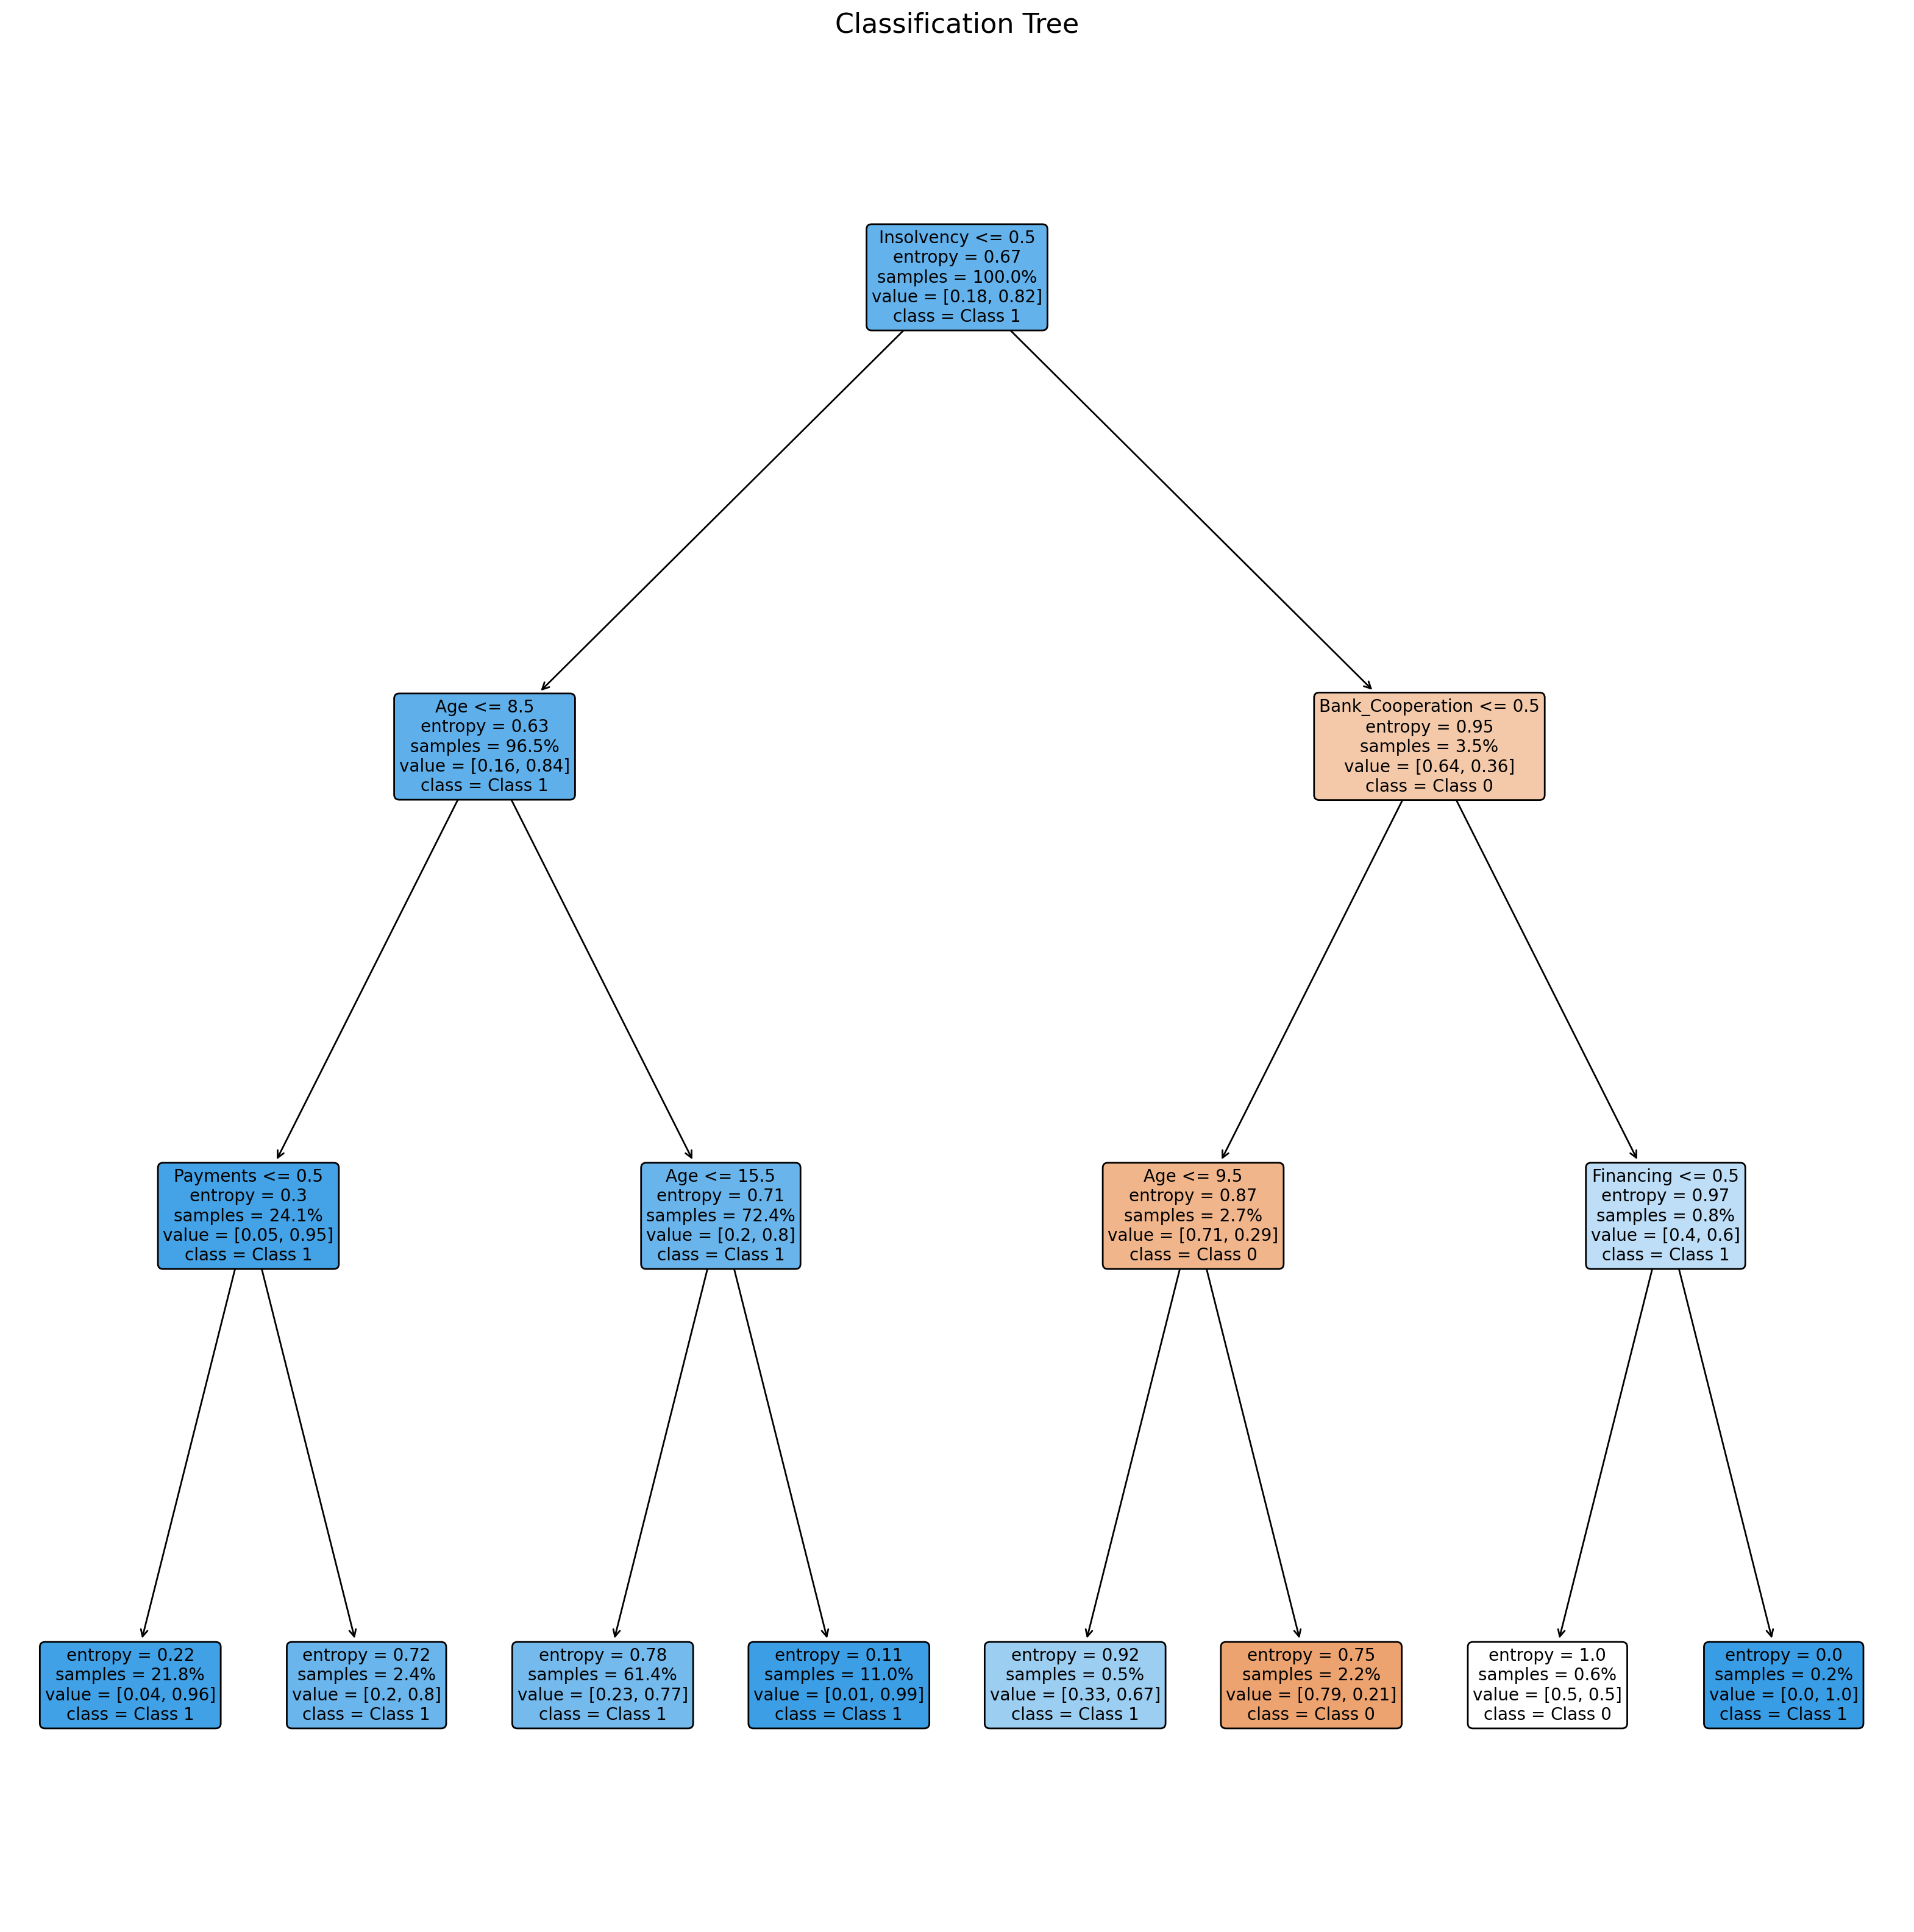

|--- Insolvency <= 0.50
|   |--- Age <= 8.50
|   |   |--- Payments <= 0.50
|   |   |   |--- class: 1
|   |   |--- Payments >  0.50
|   |   |   |--- class: 1
|   |--- Age >  8.50
|   |   |--- Age <= 15.50
|   |   |   |--- class: 1
|   |   |--- Age >  15.50
|   |   |   |--- class: 1
|--- Insolvency >  0.50
|   |--- Bank_Cooperation <= 0.50
|   |   |--- Age <= 9.50
|   |   |   |--- class: 1
|   |   |--- Age >  9.50
|   |   |   |--- class: 0
|   |--- Bank_Cooperation >  0.50
|   |   |--- Financing <= 0.50
|   |   |   |--- class: 0
|   |   |--- Financing >  0.50
|   |   |   |--- class: 1



In [84]:
model = DTC(criterion='entropy', max_depth=3, random_state=0)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Improved tree visualization
plt.figure(figsize=(20, 20), dpi=200)  # Increase figure size and resolution
plot_tree(
    model,
    feature_names=feature_names,  
    class_names=["Class 0", "Class 1"], 
    filled=True,  
    rounded=True,  
    precision=2,  
    fontsize=10,  
    proportion=True  
)

# Add title
plt.title("Classification Tree", fontsize=16)
plt.show()

# Textual representation of the tree
print(export_text(model, feature_names=feature_names))

In [85]:
# Accuracy
accuracy_score(german_fin["Status"] , model.predict(X))

0.8331573389651531

In [86]:
# Estimate cost-complexity values: trade-off between error (cost) and tree size (complexity)
ccp_path = model.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(10, random_state=1, shuffle=True)

In [87]:
# Extract the optimal value of the previously estimated cost-complexity values
grid = skm.GridSearchCV(
    model, 
    {'ccp_alpha': ccp_path.ccp_alphas}, 
    refit=True, 
    cv=kfold, 
    scoring='accuracy'
)
grid.fit(X_train, y_train)
grid.best_score_

0.8233630952380953

[Text(0.6, 0.875, 'Insolvency <= 0.5\nentropy = 0.673\nsamples = 634\nvalue = [112, 522]'),
 Text(0.4, 0.625, 'Age <= 8.5\nentropy = 0.635\nsamples = 612\nvalue = [98, 514]'),
 Text(0.2, 0.375, 'entropy = 0.296\nsamples = 153\nvalue = [8, 145]'),
 Text(0.6, 0.375, 'Age <= 15.5\nentropy = 0.714\nsamples = 459\nvalue = [90, 369]'),
 Text(0.4, 0.125, 'entropy = 0.776\nsamples = 389\nvalue = [89, 300]'),
 Text(0.8, 0.125, 'entropy = 0.108\nsamples = 70\nvalue = [1, 69]'),
 Text(0.8, 0.625, 'entropy = 0.946\nsamples = 22\nvalue = [14, 8]')]

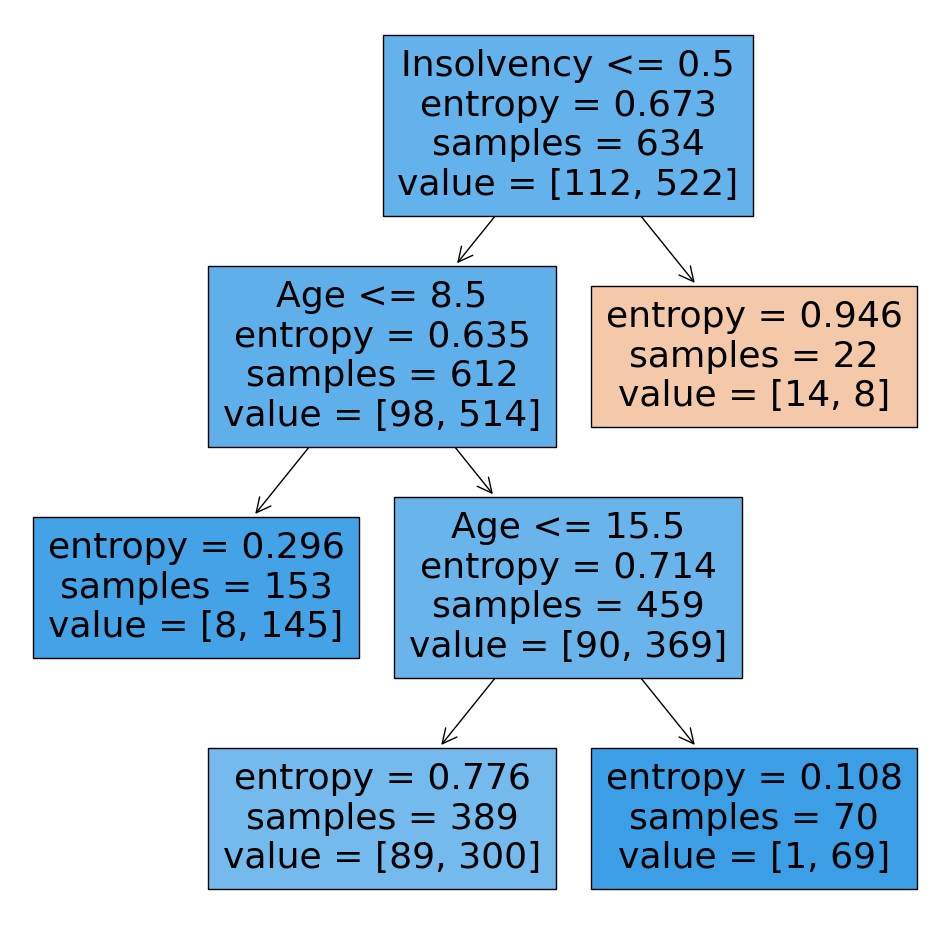

In [88]:
# Visualize the pruned tree
ax = subplots(figsize=(12, 12))[1]
best_ = grid.best_estimator_
plot_tree(best_, feature_names=feature_names, ax=ax, filled=True)

## Classification Groups

In the classification model, companies were divided into four main groups, or **leaves**, based on insolvency status and company age.

- **Group 0**: This group contains 153 companies, of which 145 are active and only 8 are inactive. These companies have an age of **8 years or less** and `Insolvency = 0`.

- **Group 1**: This group includes companies with an age greater than 8 and less than or equal to 15 years, and `Insolvency = 0`. It contains 389 companies, including 300 active and 89 inactive companies.

- **Group 2**: This group consists of companies with an age greater than 15 years and `Insolvency = 0`. Almost all of them are active, with 69 active companies out of 70 and only 1 inactive company.

- **Group 3**: This group includes companies with `Insolvency = 1`. The distribution is more uncertain: out of 22 companies, 14 are inactive and 8 are active. This indicates a more heterogeneous group.

In [89]:
# Add bagging
# Create the model
bagging_model = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=4),
    n_estimators=100,
    random_state=44,
    bootstrap=True
)

# Train the model
bagging_model.fit(X_train, y_train)

# Predictions and performance
bagging_predictions = bagging_model.predict(X_test)
bagging_accuracy = accuracy_score(y_test, bagging_predictions)

print(f"Accuracy (Bagging): {bagging_accuracy:.4f}")

Accuracy (Bagging): 0.8275


/Users/Elisa/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


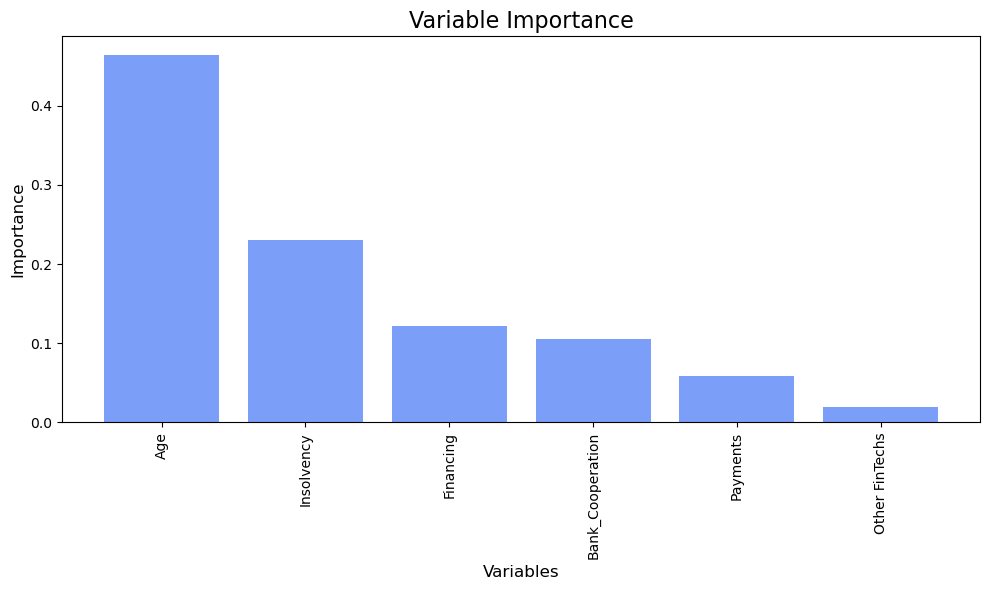

In [90]:
# Variable importance (average importance across all trees)
feature_importances = np.mean(
    [tree.feature_importances_ for tree in bagging_model.estimators_], 
    axis=0
)
sorted_indices = np.argsort(feature_importances)[::-1]

# Variable importance plot (classification)
plt.figure(figsize=(10, 6))
plt.title("Variable Importance", fontsize=16)
plt.bar(
    range(X.shape[1]), 
    feature_importances[sorted_indices], 
    align="center", 
    color=[cm.coolwarm(0.2)]
)
plt.xticks(range(X.shape[1]), X.columns[sorted_indices], rotation=90)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()

In [91]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, bagging_predictions)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[  2  51]
 [  3 257]]


In [92]:
# Classification report (Precision, Recall, F1-score)
print("Classification Report:\n", classification_report(y_test, bagging_predictions))

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.04      0.07        53
           1       0.83      0.99      0.90       260

    accuracy                           0.83       313
   macro avg       0.62      0.51      0.49       313
weighted avg       0.76      0.83      0.76       313



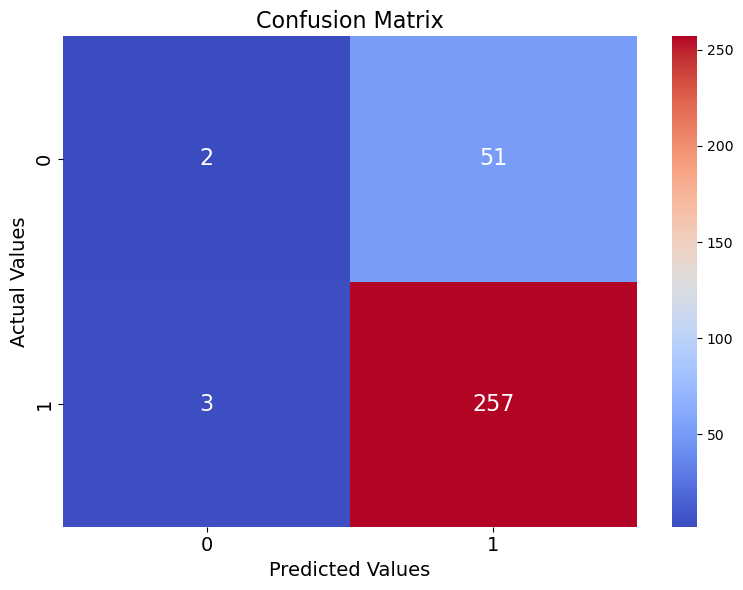

In [93]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='coolwarm', 
    xticklabels=["0", "1"], 
    yticklabels=["0", "1"],
    annot_kws={'size': 16}
)  

plt.xticks(fontsize=14)  
plt.yticks(fontsize=14)  

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Values", fontsize=14)
plt.ylabel("Actual Values", fontsize=14)

plt.tight_layout()
plt.show()

In [94]:
# Define conditions to assign values to the "Tree" column
conditions = [
    (german_fin["Insolvency"] <= 0.5) & (german_fin["Age"] <= 8.5),                     # Leaf 1
    (german_fin["Insolvency"] <= 0.5) & (german_fin["Age"] > 8.5) & (german_fin["Age"] <= 15.5),  # Leaf 2
    (german_fin["Insolvency"] <= 0.5) & (german_fin["Age"] > 15.5),                    # Leaf 3
    (german_fin["Insolvency"] > 0.5)                                                   # Leaf 4
]

# Values corresponding to the conditions (one for each leaf)
values = [0, 1, 2, 3]

# Apply the conditions to the "Tree" column
german_fin["Tree"] = np.select(conditions, values)

In [95]:
# Create the new "Tree" column
german_fin["Tree"] = np.select(conditions, values, default=-1)  # -1 if no condition is met

In [96]:
# Load the Germany shapefile
shapefile = 'germany_map.geojson'
geo_data = gpd.read_file(shapefile)

In [97]:
# Extract Leitzone from the shapefile (first two digits of the ZIP code)
geo_data['Leitzone'] = geo_data['plz'].astype(str).str[:2]

In [98]:
# Filter only German companies
german_only = german_fin[german_fin['Country'] == 'Germany'].copy()

In [99]:
# Create the Leitzone for these companies as well
german_only['Postcode'] = german_only['Postcode'].astype(str)
german_only['Leitzone'] = german_only['Postcode'].str[:2]

In [100]:
# Find the most common segment (Tree) for each Leitzone
segment_per_leitzone = (
    german_only.groupby('Leitzone')['Tree']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)

In [101]:
# Merge the segment information into the GeoDataFrame
geo_data = geo_data.merge(segment_per_leitzone, on='Leitzone', how='left')

In [102]:
# Colors for the segments
segmenti_unici = geo_data['Tree'].dropna().unique()
colori_base = [cm.coolwarm(1), cm.coolwarm(0.15), cm.coolwarm(0.99), cm.coolwarm(0.8)]
colori = colori_base[:len(segmenti_unici)] + [cm.coolwarm(0.5)]  # Add a color for missing values

In [103]:
# Map each segment to a numeric code
segment_dict = {segmento: i for i, segmento in enumerate(segmenti_unici)}
geo_data['Tree_Code'] = geo_data['Tree'].map(segment_dict)
geo_data['Tree_Code'] = geo_data['Tree_Code'].fillna(-1)  # -1 for missing data

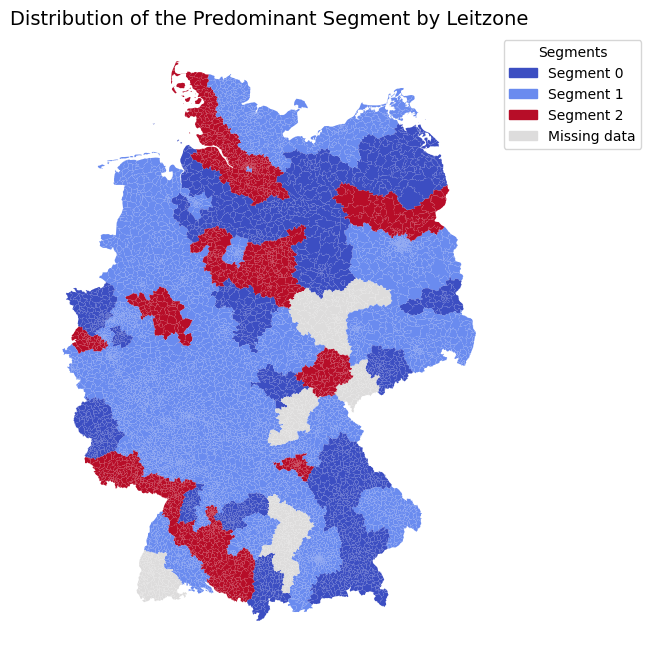

In [104]:
cmap_segment = ListedColormap(colori)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
geo_data.plot(column='Tree_Code', cmap=cmap_segment, legend=False, ax=ax)

ax.set_title('Distribution of the Predominant Segment by Leitzone', fontsize=14)
ax.axis('off')

# Create ordered dictionary
segment_dict = {segmento: i for i, segmento in enumerate(sorted(segmenti_unici))}
geo_data['Tree_Code'] = geo_data['Tree'].map(segment_dict)
geo_data['Tree_Code'] = geo_data['Tree_Code'].fillna(-1)

# Recreate the ordered list of segments
segmenti_ordinati = sorted(segment_dict.keys(), key=lambda x: segment_dict[x])

# Build the legend in the correct order
legend_labels = [
    mpatches.Patch(color=colori[segment_dict[segment]], label=f"Segment {segment_dict[segment]}")
    for segment in segmenti_ordinati
]
legend_labels.append(mpatches.Patch(color=cm.coolwarm(0.5), label="Missing data"))

ax.legend(handles=legend_labels, title="Segments", loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

## Geographic Distribution of Classification Groups

A map of Germany was created using only companies headquartered in Germany. Each `Leitzone`, representing a geographical area, was assigned a colour according to the most represented classification group within that area. In other words, each zone was classified based on the modal group of the companies located there.

Areas with no available data were assigned to a separate group and displayed in grey.

The analysis shows that **Group 1** is the most common group and is mainly concentrated in central-western Germany. **Groups 0 and 2** are distributed relatively evenly across the rest of the country, although they are less prevalent than Group 1.

**Group 3** is not represented on the map. This group is the only one characterized by `Insolvency = 1` and contains the smallest number of observations. Therefore, it is plausible that Group 3 does not appear as the predominant group in any geographical area.

## Conclusions

This study applied two supervised learning models—**logistic regression** and a **classification tree**—to predict the `Status` variable using four predictors:

- `Age`
- `Bank_Cooperation`
- `Insolvency`
- `Segment`

Both models showed good overall performance, confirming the validity of the selected set of predictors.

Using both models made it possible to validate the results obtained. Although the models rely on different mechanisms, they led to consistent conclusions. Logistic regression provides a more interpretable and linear representation of the relationships between the variables, whereas the classification tree offers greater flexibility and can capture non-linear relationships.

The two models are therefore different but complementary approaches. Their agreement reinforces the reliability of the predictions and suggests that the `Status` variable can be effectively predicted using multiple supervised learning methods.

For further details, please refer to the attached code, which includes additional statistics and more in-depth analyses.